## Imports and utilitaries

Run all cells in this section before simulating.


In [2]:
# copied from all_possible_paths.py
 
### In this script I can try all the different combinations of actions for the AV agents.
import itertools
import os
import pandas as pd
import numpy as np
import csv
import torch
from tensordict.nn import TensorDictModule, TensorDictSequential
from torchrl.envs.libs.pettingzoo import PettingZooWrapper
from torchrl.envs.transforms import TransformedEnv, RewardSum
from torchrl.envs.utils import check_env_specs
from torch import nn
from torchrl._utils import logger as torchrl_logger
from torchrl.collectors import SyncDataCollector
from torchrl.data import TensorDictReplayBuffer
from torchrl.data.replay_buffers.samplers import SamplerWithoutReplacement
from torchrl.data.replay_buffers.storages import LazyTensorStorage
from torchrl.modules import EGreedyModule, QValueModule, SafeSequential
from torchrl.modules.models.multiagent import MultiAgentMLP
from torchrl.objectives import SoftUpdate, ValueEstimators, DQNLoss

from routerl import TrafficEnvironment

from routerl.keychain import Keychain as kc
from routerl.utilities import get_params

os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"
import matplotlib.pyplot as plt

C:\Users\Utilisateur\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\torchrl\data\replay_buffers\samplers.py:37: UserWarning: Failed to import torchrl C++ binaries. Some modules (eg, prioritized replay buffers) may not work with your installation. This is likely due to a discrepancy between your package version and the PyTorch version. Make sure both are compatible. Usually, torchrl majors follow the pytorch majors within a few days around the release. For instance, TorchRL 0.5 requires PyTorch 2.4.0, and TorchRL 0.6 requires PyTorch 2.5.0.
  warnings.warn(EXTENSION_WARNING)


In [3]:
def update_trafficlight(t0,t1,ty):

    '''
    t0 = time of green light for route 0, red light for route 1 \\
    t1 = time of red light for route 0, green light for route 1 \\
    ty = time of yellow light for both routes (symmetrical)

    This function updates the network file used for simulations. \\
    !!! Verify paths exist on your machine !!!
    '''

    # template file
    read_file_name = "../networks/two_route_trafficlight/two_route_trafficlight.net.xml"

    # path within the RouteRL module
    write_file_name = "C:/Users/Utilisateur/AppData/Local/Packages/PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0/LocalCache/local-packages/Python313/site-packages/routerl/networks/two_route_trafficlight/two_route_trafficlight.net.xml"
    
    # path within the /networks/ folder
    network_file_name = "../networks/two_route_trafficlight/two_route_trafficlight.net.xml"

    tllogic = []
    tllogic.append( "\t<tlLogic id=\"J2\" type=\"static\" programID=\"0\" offset=\"0\">\n")
    tllogic.append( "\t\t<phase duration=\"%s\" state=\"Gr\"/>\n"%(t1))
    tllogic.append( "\t\t<phase duration=\"%s\"  state=\"yr\"/>\n"%(ty))
    tllogic.append( "\t\t<phase duration=\"%s\" state=\"rG\"/>\n"%(t0))
    tllogic.append( "\t\t<phase duration=\"%s\"  state=\"ry\"/>\n"%(ty))
    tllogic.append( "\t</tlLogic>\n")

    with open(read_file_name, "r") as fr:
        lines = fr.readlines()
        print(lines)

    with open(write_file_name, "w") as fw:
        fw.writelines(lines[:76])
        fw.writelines(tllogic)
        fw.writelines(lines[82:])

    with open(network_file_name, "w") as fw:
        fw.writelines(lines[:76])
        fw.writelines(tllogic)
        fw.writelines(lines[82:])
    
    return None

def create_environment(nb_agents=23):
    env = TrafficEnvironment(
        agent_parameters={
            "num_agents": nb_agents, 
            "new_machines_after_mutation": 10, 
            "machine_parameters": {
                "behavior": "selfish"
                }
            },
        simulator_parameters={
            "network_name": "two_route_trafficlight",
            "sumo_type": "sumo"
            },
        path_generation_parameters={
            "origins": ["E0"],
            "destinations": ["E2"],
            "number_of_paths": 2
            }
        )
    return env

def simulate(nb_agents=23):

    env = create_environment(nb_agents)
    env.start()
    env.mutation()

    actions = [0, 1]
    print("env.human_agents", env.human_agents)
    print("env.machine_agents", env.machine_agents)
    print("\n")

    env.reset()

    i = 0
    k = 1
    for combination in itertools.product(actions, repeat=len(env.possible_agents)):
        i += 1
        for action in combination:
            env.step(action)
        if i > k*1024/10:
            print("%s combinations out of 1024 tested, %s%s remaining"%(i,(10-k)*10,"%"))
            k += 1

        env.reset()
    
    env.stop_simulation()

def build_df(i):

    '''
    Returns the payoff matrix from the last experiment as a pandas DataFrame.
    '''
    
    df = pd.read_csv("training_records/episodes/ep"+str(i)+".csv")
    df = df[df["kind"] == "AV"]
    df = df.sort_values(by="start_time").reset_index(drop=True)
    df["reward"] = -1*df["travel_time"]
    df = df[["reward","action"]]
    return df

def write_line(i,df):
    '''
    Auxiliary function for record_experiment()
    '''
    line = str(i)
    for i in range(10):
        line = line + "," + str(df["reward"].values[i])
    return line

def record_experiment(file_name):

    '''
    Writes down the payoff matrix from the last experiment into the file (file name entered as input)
    '''

    with open(file_name, "w") as f:
        f.write("id,0,1,2,3,4,5,6,7,8,9\n")
        for i in range(1024):
            data = build_df(i+1)
            text = write_line(i,data)
            f.write(text+"\n")

In [ ]:
def id_to_strategy(id):
    '''
    INPUT : id = integer from [0,1023]

    OUTPUT : strategy = array of size 10, binary representation of number id
    '''
    strategy = [0 for _ in range(10)]
    i = 0
    while id > 0:
        if id % 2 == 1:
            strategy[9-i] = 1
        id = id//2
        i += 1
    return strategy

def strategy_to_id(s):
    '''
    INPUT : strategy = array of size 10, binary representation of number id

    OUTPUT : id = integer within [0,1023]
    '''
    id = 0
    for i in range(10):
        id += s[i]*(2**(9-i))
    return id

def coalition_to_strategy(coalition):
    '''
    INPUT : coalition = subset of [0,9]

    OUTPUT : strategy = array of size 10, strategy[i] = 1 iff i is in the coalition

    NOTE : strategy_to_coalition(id_to_strategy()) may be used to map an integer to a subset of [0,9]
    '''
    s = [0 for _ in range(10)]
    for i in coalition:
        s[i] = 1
    return s

def strategy_to_coalition(s):
    '''
    INPUT : strategy = array of size 10
    
    OUTPUT : coalition = subset of [0,9], strategy[i] = 1 iff i is in the coalition

    NOTE : strategy_to_coalition(id_to_strategy()) may be used to map an integer to a subset of [0,9]
    '''
    coalition = []
    for i in range(10):
        if s[i] == 1:
            coalition.append(i)
    return coalition

def build_rewardtable(file_name):

    '''
    Returns the payoff matrix from an experiment (stored in the file given as input) as an array.

    !! Will crash if the file does not exist.
    '''

    df_reward = pd.read_csv(file_name)
    tab = np.zeros((10,1024))
    for i in range(10):
        tab[i] = df_reward[str(i)].values
    return tab

def custom_df(tl_list, custom_filename = "reward_df_custom.csv"):

    '''
    tl_list is an array of size 11. For each i in [0...10], tl_list is a tuple (tl_0,tl_1,tl_y,nb_agents), representing specific parameters of a network with static traffic lights.

    custom_df builds the payoff matrix of a network with dynamic traffic lights, where whenever n AVs choose route 1, traffic lights are set to tl_list[n]
    '''

    assert len(tl_list) == 11

    f = open(custom_filename,"w")
    
    f.write("id,0,1,2,3,4,5,6,7,8,9\n")
    for id in range(1024):

        s = id_to_strategy(id)
        n_1 = 0
        for j in range(10):
            n_1 += s[j]
        tl_0,tl_1,tl_y,nb_agents = tl_list[n_1]

        try:
            df_reward = pd.read_csv("reward_df_%s_%s_%s_%sagents.csv"%(tl_0,tl_1,tl_y,nb_agents))
        except:
            print("Reward table for tl_0 = %s, tl_1 = %s, tl_y = %s and %s agents was not found. Running..."%(tl_0,tl_1,tl_y,nb_agents))
            run(tl_0,tl_1,tl_y,nb_agents)
            df_reward = pd.read_csv("reward_df_%s_%s_%s_%sagents.csv"%(tl_0,tl_1,tl_y,nb_agents))

        text = str(id)
        tab_reward = [[] for _ in range(10)]
        for i in range(10):
            tab_reward[i] = df_reward[str(i)].values
            text = text + "," + str(float(tab_reward[i][id]))

        f.write(text+"\n")

In [5]:
def reward(i,id):
    return float(tab_reward[i][id])

def id_to_reward(id):
    return [reward(i,id) for i in range(10)]

def s_to_reward(s):
    id = strategy_to_id(s)
    return id_to_reward(id)

def neighbouring_strategies(s):

    '''
    INPUT : s = array of size n, describing the joint actions of the 10 AVs (route 0 or 1)

    OUTPUT : array of all 10 joint actions, each one with one of the AVs deviating from s
    '''

    neigh = [ [s[j] for j in range(10)] for _ in range(10)]
    for i in range(10):
        neigh[i][i] = 1 - neigh[i][i]
    return neigh

def neighbouring_ids(id):
    
    '''
    goes from the space of ids (integers in 0..1023) to strategies, then to neigbouring strategies (see neighbouring_strategies()), and back to ids.
    '''

    s = id_to_strategy(id)
    t = neighbouring_strategies(s)
    neigh = []
    for i in range(10):
        neigh.append(strategy_to_id(t[i]))
    return neigh

def nash_deviation(s):
    
    '''
    for a given strategy/joint action s, returns an array of size 10 dev.

    For i in 0..9, dev[i] is what the AV number i can gain by deviating ALONE from s.
    '''

    rew = s_to_reward(s)
    neigh = neighbouring_strategies(s)
    dev = []
    for i in range(10):
        alternative = s_to_reward(neigh[i])[i]
        dev.append(alternative - rew[i])
    return dev

def nash_equilibrium(s):
    
    '''
    runs nash_deviation(s), verifies if any AV can gain by deviating from s, and answers whether s is a Nash equilibrium.
    '''

    dev = nash_deviation(s)
    for i in range(1,10):
        # we do not verify if the first AV can deviate. Otherwise, no non-trivial NE will be found.
        if dev[i] > 0:
            return False
    return True

def nash_equilibrium_eps(s,eps=0):
    dev = nash_deviation(s)
    for i in range(1,10):
        # we do not verify if the first AV can deviate. Otherwise, no non-trivial NE will be found.
        if dev[i] > eps:
            return False
    return True

def strong_nash_equilibrium(s):
    
    '''
    verifies that no subset of the set of AVs can deviate from s, allowing every member of the subset to reduce travel time.
    '''

    rew = s_to_reward(s)
    list_c = []
    for id in range(1,1024):
        coalition = strategy_to_coalition(id_to_strategy(id))
        neigh_s = [s[i] for i in range(10)]
        for i in coalition:
            neigh_s[i] = 1 - s[i]
        alt = s_to_reward(neigh_s)
        coalition_deviates = True
        for i in coalition:
            if alt[i] - rew[i] < 0:
                coalition_deviates = False
        if coalition_deviates:
            list_c.append(coalition)
    for c in list_c:
        print(c)
    return len(list_c) == 0

def strong_nash_equilibrium_TU(s):

    '''
    verifies that no subset of the set of AVs can deviate from s, improving their average travel time.
    '''

    rew = s_to_reward(s)
    list_c = []
    for id in range(1,1024):
        coalition = strategy_to_coalition(id_to_strategy(id))
        neigh_s = [s[i] for i in range(10)]
        for i in coalition:
            neigh_s[i] = 1 - s[i]
        alt = s_to_reward(neigh_s)

        gain = 0
        for i in coalition:
            gain += alt[i] - rew[i]
        if gain > 0:
            list_c.append(coalition)
    
    for c in list_c:
        print(c)
    return len(list_c) == 0

## Simulation

`run(tl_0, tl_1, tl_y, nbagents)` :
* generates a two-route-trafficlight network with the specified traffic light times (writes a .net.xml file **both** within the RouteRL module (for execution), and within the ..\networks\two_route_trafficlight folder (for safekeeping). Make sure both paths exist on the machine otherwise it won't run.);
* initializes the SUMO environment with the specified number of agents;
* runs the simulation for all 1024 possible AV joint actions;
* writes the payoff matrix inside the `reward_df_(tl_0)_(tl_1)_(tl_y)_(nbagents)agents.csv` file.

In [6]:
def run(tl_0, tl_1, tl_y, nbagents):

    '''
    - generates a two-route-trafficlight network with the specified traffic light times (writes a .net.xml file **both** within the RouteRL module (for execution), and within the ../networks/two_route_trafficlight folder (for safekeeping). Make sure both paths exist on the machine otherwise it won't run.);
    - initializes the SUMO environment with the specified number of agents;
    - runs the simulation for all 1024 possible AV joint actions;
    - writes the payoff matrix inside the `reward_df_(tl_0)_(tl_1)_(tl_y)_(nbagents)agents.csv` file.
    '''

    filename = "reward_df_%s_%s_%s_%sagents.csv"%(tl_0,tl_1, tl_y, nbagents)
    update_trafficlight(tl_0, tl_1, tl_y)
    simulate(nbagents)
    record_experiment(filename)

In [ ]:
# Test run: lights are green for 45 seconds on route 0 and 5 seconds on route 1. There are 23 agents.

run(45,5,5,23)

['<?xml version="1.0" encoding="UTF-8"?>\n', '\n', '<!-- generated on 2025-04-16 16:19:46 by Eclipse SUMO netedit Version 1.22.0\n', '<neteditConfiguration xmlns:xsi="http://www.w3.org/2001/XMLSchema-instance" xsi:noNamespaceSchemaLocation="http://sumo.dlr.de/xsd/neteditConfiguration.xsd">\n', '\n', '    <input>\n', '        <sumo-net-file value="C:\\Users\\Utilisateur\\Desktop\\projectrouterl\\venv\\Lib\\site-packages\\routerl\\networks\\two_route_trafficlight\\two_route_trafficlight.net.xml"/>\n', '    </input>\n', '\n', '    <output>\n', '        <output-file value="C:\\Users\\Utilisateur\\Desktop\\projectrouterl\\venv\\Lib\\site-packages\\routerl\\networks\\two_route_trafficlight\\two_route_trafficlight.net.xml"/>\n', '    </output>\n', '\n', '    <processing>\n', '        <geometry.min-radius.fix.railways value="false"/>\n', '        <geometry.max-grade.fix value="false"/>\n', '        <offset.disable-normalization value="true"/>\n', '        <lefthand value="0"/>\n', '    </proce

In [ ]:
# list_runs can be any list of tuples (tl_0,tl_1,tl_y,nb_agents) of parameters.

list_runs = [(45,5,5,23)]

# This script will not run if any one of the "runs" has not been generated earlier.
# Consider adding a try loop if you need to use this script.

for tl_0,tl_1,tl_y,nb_agents in list_runs:
    filename = "reward_df_%s_%s_%s_%sagents.csv"%(tl_0,tl_1, tl_y, nb_agents)
    tab_reward = build_rewardtable(filename)

    print(tl_0,tl_1, tl_y, nb_agents) # prints parameters
    
    print(nash_deviation(id_to_strategy(0))) # prints the potential gains for each AV to be the first one to reroute from 0 to 1

    # prints all the joint actions that are Nash equilibria
    for id in range(1024):
        if nash_equilibrium(id_to_strategy(id)):
            print(id_to_strategy(id))
    
    print(nash_equilibrium(id_to_strategy(0)))
    if nash_equilibrium(id_to_strategy(0)):
        strong_nash_equilibrium(id_to_strategy(0))
    

10 40 5 23
[0.8166666666666667, 0.7833333333333332, 1.6999999999999997, 1.6333333333333333, 2.183333333333333, 2.1333333333333337, 2.75, 2.2666666666666666, 2.216666666666667, 2.7666666666666666]
[0, 1, 1, 1, 1, 1, 1, 1, 1, 1]
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
False
15 35 5 23
[0.6666666666666665, 0.6499999999999997, 0.7333333333333332, 0.6500000000000001, 1.2000000000000002, 1.1333333333333333, 0.8, 0.8500000000000001, 0.8333333333333333, 1.1666666666666665]
[0, 1, 1, 1, 1, 1, 0, 1, 1, 1]
[1, 1, 1, 1, 1, 1, 0, 0, 1, 1]
False
20 30 5 23
[-0.18333333333333346, -0.21666666666666667, 0.5333333333333332, 0.4666666666666668, 0.2833333333333332, 0.25, -0.15000000000000002, -0.11666666666666659, 0.5499999999999998, 0.29999999999999993]
[0, 0, 1, 1, 1, 1, 0, 0, 0, 1]
[1, 0, 0, 1, 1, 1, 0, 0, 0, 1]
False
25 25 5 23
[-0.2666666666666667, -0.28333333333333344, -0.21666666666666679, -0.2833333333333333, 0.2333333333333334, 0.16666666666666674, -0.3500000000000001, -0.29999999999999993, -0.31666666666

In [9]:
snash_x, snash_y = [], []
nash_x, nash_y = [], []
notnash_x, notnash_y = [], []

for tl_0 in range(5,45,5):
    for tl_1 in range(5,45,5):
        filename = "reward_df_%s_%s_%s_%sagents.csv"%(tl_0,tl_1, 5, 23)
        try:
            tab_reward = build_rewardtable(filename)
            if nash_equilibrium(id_to_strategy(0)):
                if strong_nash_equilibrium(id_to_strategy(0)):
                    snash_x.append(tl_0)
                    snash_y.append(tl_1)
                else:
                    nash_x.append(tl_0)
                    nash_y.append(tl_1)
            else:
                notnash_x.append(tl_0)
                notnash_y.append(tl_1)
        except:
            print(tl_0,tl_1, 5, 23)
            run(tl_0,tl_1,5,23)
            tab_reward = build_rewardtable(filename)
            if nash_equilibrium(id_to_strategy(0)):
                if strong_nash_equilibrium(id_to_strategy(0)):
                    snash_x.append(tl_0)
                    snash_y.append(tl_1)
                else:
                    nash_x.append(tl_0)
                    nash_y.append(tl_1)
            else:
                notnash_x.append(tl_0)
                notnash_y.append(tl_1)

plt.scatter(snash_x, snash_y, color="g", label="strong Nash equilibria")
plt.scatter(nash_x, nash_y, color="y", label="not strong Nash equilibria")
plt.scatter(notnash_x, notnash_y, color="r", label="not Nash equilibria")
plt.xlabel("Traffic light 0")
plt.ylabel("Traffic light 1")
plt.title("Is all-AVs-on-route-0 a (strong) Nash equilibrium?")
plt.legend()
plt.show()


5 5 5 23
['<?xml version="1.0" encoding="UTF-8"?>\n', '\n', '<!-- generated on 2025-04-16 16:19:46 by Eclipse SUMO netedit Version 1.22.0\n', '<neteditConfiguration xmlns:xsi="http://www.w3.org/2001/XMLSchema-instance" xsi:noNamespaceSchemaLocation="http://sumo.dlr.de/xsd/neteditConfiguration.xsd">\n', '\n', '    <input>\n', '        <sumo-net-file value="C:\\Users\\Utilisateur\\Desktop\\projectrouterl\\venv\\Lib\\site-packages\\routerl\\networks\\two_route_trafficlight\\two_route_trafficlight.net.xml"/>\n', '    </input>\n', '\n', '    <output>\n', '        <output-file value="C:\\Users\\Utilisateur\\Desktop\\projectrouterl\\venv\\Lib\\site-packages\\routerl\\networks\\two_route_trafficlight\\two_route_trafficlight.net.xml"/>\n', '    </output>\n', '\n', '    <processing>\n', '        <geometry.min-radius.fix.railways value="false"/>\n', '        <geometry.max-grade.fix value="false"/>\n', '        <offset.disable-normalization value="true"/>\n', '        <lefthand value="0"/>\n', '  

KeyboardInterrupt: 

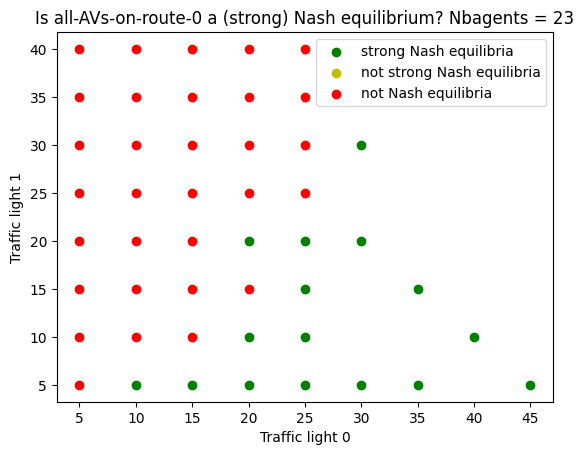

In [ ]:
# Verifying, among all sets of parameters already ran, under which sets of static traffic light parameters
# having all AVs on route 0 is a (eventually strong) Nash equilibrium.

snash_x, snash_y = [], []
nash_x, nash_y = [], []
notnash_x, notnash_y = [], []

nbagents = 23

for tl_0 in range(5,50,5):
    for tl_1 in range(5,45,5):
        filename = "reward_df_%s_%s_%s_%sagents.csv"%(tl_0,tl_1, 5, nbagents)
        try:
            tab_reward = build_rewardtable(filename)
            if nash_equilibrium(id_to_strategy(0)):
                if strong_nash_equilibrium(id_to_strategy(0)):
                    snash_x.append(tl_0)
                    snash_y.append(tl_1)
                else:
                    nash_x.append(tl_0)
                    nash_y.append(tl_1)
            else:
                notnash_x.append(tl_0)
                notnash_y.append(tl_1)
        except:
            # Running a simulation takes way more time than using reward tables that have already been calculated.
            x=0

plt.scatter(snash_x, snash_y, color="g", label="strong Nash equilibria")
plt.scatter(nash_x, nash_y, color="y", label="not strong Nash equilibria")
plt.scatter(notnash_x, notnash_y, color="r", label="not Nash equilibria")
plt.xlabel("Traffic light 0")
plt.ylabel("Traffic light 1")
plt.legend()
plt.title("Is all-AVs-on-route-0 a (strong) Nash equilibrium? Nbagents = %s"%(nbagents))
plt.show()

In [17]:
##################### Environment Creation #####################
# params = get_params("params.json")
# print(params[kc.PLOTTER][kc.RECORDS_FOLDER])

# env.start()
###################### Human Learning #####################
#num_episodes = 0
#
#for episode in range(num_episodes):
#    env.step()
#
##################### Mutation #####################
#env.mutation()

In [6]:
## How to check whether a custom dynamic trafficlight system is a NE and a SNE

tl_0_list = [i for i in range(45,5,-1)]
for tl_0 in tl_0_list:
    print("tl_0 = ",tl_0)
    tl_list = [(tl_0,50-tl_0,5,23) if nb_1 < 5 else (5,45,5,23) for nb_1 in range(11)]

    custom_df(tl_list)
    tab_reward = build_rewardtable("reward_df_custom.csv")
    print(nash_equilibrium(id_to_strategy(0)))
    print(strong_nash_equilibrium(id_to_strategy(0)))


tl_0 =  45
True
True
tl_0 =  44
True
True
tl_0 =  43
True
True
tl_0 =  42
True
True
tl_0 =  41
True
True
tl_0 =  40
True
True
tl_0 =  39
Reward table for tl_0 = 39, tl_1 = 11, tl_y = 5 and 23 agents was not found. Running...
['<?xml version="1.0" encoding="UTF-8"?>\n', '\n', '<!-- generated on 2025-04-16 16:19:46 by Eclipse SUMO netedit Version 1.22.0\n', '<neteditConfiguration xmlns:xsi="http://www.w3.org/2001/XMLSchema-instance" xsi:noNamespaceSchemaLocation="http://sumo.dlr.de/xsd/neteditConfiguration.xsd">\n', '\n', '    <input>\n', '        <sumo-net-file value="C:\\Users\\Utilisateur\\Desktop\\projectrouterl\\venv\\Lib\\site-packages\\routerl\\networks\\two_route_trafficlight\\two_route_trafficlight.net.xml"/>\n', '    </input>\n', '\n', '    <output>\n', '        <output-file value="C:\\Users\\Utilisateur\\Desktop\\projectrouterl\\venv\\Lib\\site-packages\\routerl\\networks\\two_route_trafficlight\\two_route_trafficlight.net.xml"/>\n', '    </output>\n', '\n', '    <processing>\

(30,20) below threshold, (5,45) above threshold
(30,20) below threshold, (6,44) above threshold
(30,20) below threshold, (7,43) above threshold
(30,20) below threshold, (8,42) above threshold
(30,20) below threshold, (9,41) above threshold
(30,20) below threshold, (10,40) above threshold
(30,20) below threshold, (11,39) above threshold
(30,20) below threshold, (12,38) above threshold
(30,20) below threshold, (13,37) above threshold
(30,20) below threshold, (14,36) above threshold
(30,20) below threshold, (15,35) above threshold
(30,20) below threshold, (16,34) above threshold
(30,20) below threshold, (17,33) above threshold
(30,20) below threshold, (18,32) above threshold
(30,20) below threshold, (19,31) above threshold
(30,20) below threshold, (20,30) above threshold
(30,20) below threshold, (21,29) above threshold
(30,20) below threshold, (22,28) above threshold
[5, 9]
(30,20) below threshold, (23,27) above threshold
[5, 9]
(30,20) below threshold, (24,26) above threshold
[5, 9]
(30,

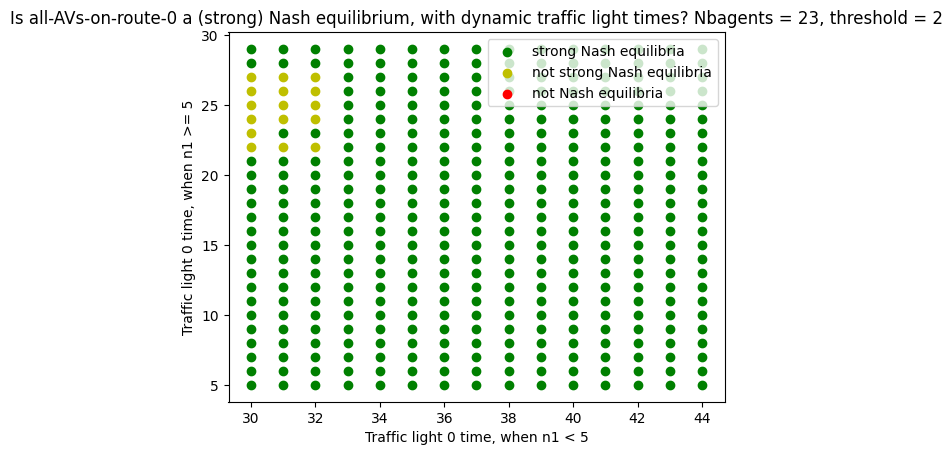

In [15]:
snash_x, snash_y = [], []
nash_x, nash_y = [], []
notnash_x, notnash_y = [], []

nbagents = 23
threshold = 2

for tl_0_below_threshold in range(30,45):
    for tl_0_above_threshold in range(5,30):

        tl_1_below_threshold = 50 - tl_0_below_threshold
        tl_1_above_threshold = 50 - tl_0_above_threshold
        print("(%s,%s) below threshold, (%s,%s) above threshold"%(tl_0_below_threshold,tl_1_below_threshold,tl_0_above_threshold,tl_1_above_threshold))

        tl_list = [(tl_0_below_threshold,tl_1_below_threshold,5,23) if nb_1 < threshold else (tl_0_above_threshold,tl_1_above_threshold,5,23) for nb_1 in range(11)]
        
        custom_df(tl_list)
        tab_reward = build_rewardtable("reward_df_custom.csv")
        if nash_equilibrium(id_to_strategy(0)):
            if strong_nash_equilibrium_TU(id_to_strategy(0)):
                snash_x.append(tl_0_below_threshold)
                snash_y.append(tl_0_above_threshold)
            else:
                nash_x.append(tl_0_below_threshold)
                nash_y.append(tl_0_above_threshold)
        else:
            notnash_x.append(tl_0_below_threshold)
            notnash_y.append(tl_0_above_threshold)

plt.scatter(snash_x, snash_y, color="g", label="strong Nash equilibria")
plt.scatter(nash_x, nash_y, color="y", label="not strong Nash equilibria")
plt.scatter(notnash_x, notnash_y, color="r", label="not Nash equilibria")
plt.xlabel("Traffic light 0 time, when n1 < 5")
plt.ylabel("Traffic light 0 time, when n1 >= 5")
plt.legend()
plt.title("Is all-AVs-on-route-0 a (strong) Nash equilibrium, with dynamic traffic light times? Nbagents = %s, threshold = %s"%(nbagents,threshold))
plt.show()